# Pertemuan 14 — Tata Kelola Data, Etika AI, dan Privasi

**Mata Kuliah:** Pengantar Data Science (Kode: 200302305)  
**Program Studi:** PJJ Informatika  
**Semester:** 4  
**Dosen:** Syahid Abdullah, S.Si, M.Kom

---

**Nama :** Junior Dany Wibisono  
**NIM  :** 250401020098  
**Kelas :** IF401  
**Angkatan:** 2025  
**Tanggal:** 26 Juli 2026

---

## Tujuan Notebook
Aktivitas hands-on ini menutup rangkaian mata kuliah dengan sisi **non-teknis namun krusial** dari Data Science: **tata kelola data, etika AI, dan privasi**. Berbeda dari Pertemuan 1–13 yang berfokus pada algoritma, di sini kita mempraktikkan **bagaimana model yang sudah kita bangun dapat digunakan secara adil, sah, dan bertanggung jawab**.

Empat bagian praktik:
1. **Deteksi & ukur bias** pada model klasifikasi menggunakan **fairness metrics** (`MetricFrame` dari **Fairlearn**) — melanjutkan model klasifikasi Pertemuan 9–10.
2. **Mitigasi bias** dengan **`ThresholdOptimizer`** (post-processing, *demographic parity*) — bandingkan sebelum vs sesudah.
3. **Perlindungan data pribadi**: simulasi **anonimisasi vs pseudonimisasi vs agregasi** pada data ber-PII, sesuai **UU PDP No. 27/2022** & **GDPR**.
4. **Checklist tata kelola**: verifikasi enam prinsip pengolahan data pribadi secara terprogram.

> Catatan: dataset dan angka dibuat **sintetis** agar reprodusibel dan tidak mengandung data pribadi nyata (prinsip *data minimization* langsung dipraktikkan).


## Langkah 0 — Setup Library

Import library. **Fairlearn** dipakai untuk mengukur & memitigasi bias (`MetricFrame`, `selection_rate`, `ThresholdOptimizer`); di Google Colab install dulu dengan `!pip install fairlearn`. **scikit-learn** menyediakan model & metrik, sedangkan **hashlib** dipakai untuk pseudonimisasi berbasis hash. Seed diset agar hasil **reprodusibel**.


In [10]:
# Di Google Colab, hapus tanda komentar baris berikut bila fairlearn belum terpasang:
# !pip install fairlearn -q

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import hashlib
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

from fairlearn.metrics import (
    MetricFrame, selection_rate,
    demographic_parity_difference, equalized_odds_difference,
)
from fairlearn.postprocessing import ThresholdOptimizer

# Seed global untuk reprodusibilitas
RNG = np.random.RandomState(42)

print('Semua library berhasil di-import.')
print('Versi pandas :', pd.__version__)
import fairlearn
print('Versi fairlearn:', fairlearn.__version__)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.5/135.5 kB 4.1 MB/s eta 0:00:00
Semua library berhasil di-import.
Versi pandas : 2.2.2
Versi fairlearn: 0.14.0


---
# BAGIAN 1 — Deteksi & Ukur Bias dengan Fairness Metrics

## Langkah 1 — Bangkitkan Dataset Rekrutmen Sintetis (dengan Bias Historis Tertanam)

Kita simulasikan kasus dari modul: **AI rekrutmen** yang dilatih dari data historis yang **didominasi satu kelompok gender**. Ini adalah contoh **Historical Bias** — data mencerminkan ketidakadilan masa lalu.

Skenario: selain fitur netral (skor tes & pengalaman), ada satu fitur **`skor_wawancara`** yang **berkorelasi dengan gender** karena penilai historis memberi skor lebih tinggi pada laki-laki. Fitur ini menjadi **variabel proxy** — dan label historis `diterima` ikut condong padanya. Kita akan lihat bahwa model bisa **mewariskan bias lewat proxy ini** meski kolom `gender` sendiri **tidak** dipakai.


In [11]:
# Langkah 1: Bangkitkan data kandidat rekrutmen sintetis
N = 1000

# Fitur netral (seharusnya jadi dasar keputusan yang adil)
skor_tes    = RNG.normal(70, 12, N).clip(0, 100)     # skor tes kompetensi
pengalaman  = RNG.poisson(4, N).clip(0, 20)          # tahun pengalaman

# Atribut sensitif: gender (0 = Perempuan, 1 = Laki-laki), proporsi seimbang
gender = RNG.binomial(1, 0.5, N)

# VARIABEL PROXY: skor wawancara historis 'bocor' bias gender
# (penilai masa lalu cenderung memberi skor lebih tinggi pada laki-laki: +8 poin)
skor_wawancara = (60 + 8 * gender + 0.2 * skor_tes + RNG.normal(0, 5, N)).clip(0, 100)

# Kualitas 'sebenarnya' kandidat — dari skor tes & pengalaman (adil)
skor_kualitas = 0.04 * skor_tes + 0.15 * pengalaman + RNG.normal(0, 0.4, N)

# Label historis condong pada skor wawancara yang bias -> ketidakadilan tertanam
skor_historis = skor_kualitas + 0.06 * skor_wawancara
diterima = (skor_historis > np.median(skor_historis)).astype(int)

df = pd.DataFrame({
    'skor_tes': skor_tes.round(1),
    'pengalaman': pengalaman,
    'skor_wawancara': skor_wawancara.round(1),
    'gender': gender,
    'diterima': diterima,
})
df['gender_label'] = df['gender'].map({0: 'Perempuan', 1: 'Laki-laki'})

print('Bentuk dataset:', df.shape)
print('\nTingkat penerimaan historis per gender:')
print(df.groupby('gender_label')['diterima'].mean().round(3))
print('\nRata-rata skor wawancara per gender (lihat kesenjangan proxy):')
print(df.groupby('gender_label')['skor_wawancara'].mean().round(1))
df.head()


Bentuk dataset: (1000, 6)

Tingkat penerimaan historis per gender:
gender_label
Laki-laki    0.582
Perempuan    0.420
Name: diterima, dtype: float64

Rata-rata skor wawancara per gender (lihat kesenjangan proxy):
gender_label
Laki-laki    81.7
Perempuan    73.8
Name: skor_wawancara, dtype: float64


,skor_tes,pengalaman,skor_wawancara,gender,diterima,gender_label
0,76.0,1,77.0,0,1,Perempuan
1,68.3,2,75.3,0,0,Perempuan
2,77.8,4,74.5,0,0,Perempuan
3,88.3,4,79.6,0,1,Perempuan
4,67.2,7,72.0,0,1,Perempuan


**Bacaan:** Tingkat penerimaan historis **Laki-laki lebih tinggi** daripada Perempuan, dan **rata-rata `skor_wawancara` laki-laki juga lebih tinggi** — padahal skor tes & pengalaman dibangkitkan dari distribusi yang sama. Ketimpangan ini mengalir dari **skor wawancara yang bias**, sebuah **variabel proxy** bagi gender — pola yang sama dengan kasus **Amazon (2018)**.


## Langkah 2 — Latih Model & Ukur Fairness Metrics

Kita latih **Logistic Regression** (model dari Pertemuan 9) pada data historis yang bias. **Penting:** atribut sensitif `gender` **tidak** kita masukkan sebagai fitur — namun **`skor_wawancara`** (variabel proxy) tetap dipakai, seperti lazimnya di dunia nyata. Kita akan melihat bahwa **menghapus kolom sensitif saja tidak cukup** untuk menjamin keadilan (*fairness through unawareness* sering gagal).

Lalu kita ukur keadilan dengan **`MetricFrame`** dari Fairlearn: membandingkan **selection rate** (proporsi diterima) dan **akurasi** antar kelompok gender.


In [12]:
# Langkah 2a: Split & latih model (gender TIDAK dipakai sebagai fitur)
fitur = ['skor_tes', 'pengalaman', 'skor_wawancara']   # gender TIDAK dipakai, skor_wawancara (proxy) dipakai
X = df[fitur]
y = df['diterima']
A = df['gender_label']   # atribut sensitif untuk audit fairness

X_tr, X_te, y_tr, y_te, A_tr, A_te = train_test_split(
    X, y, A, test_size=0.3, random_state=42, stratify=y)

model = LogisticRegression(max_iter=1000)
model.fit(X_tr, y_tr)
y_pred = model.predict(X_te)

print('Akurasi keseluruhan:', round(accuracy_score(y_te, y_pred), 3))


Akurasi keseluruhan: 0.823


In [13]:
# Langkah 2b: Ukur fairness metrics per kelompok gender
mf = MetricFrame(
    metrics={'akurasi': accuracy_score, 'selection_rate': selection_rate},
    y_true=y_te, y_pred=y_pred,
    sensitive_features=A_te)

print('=== Metrik per kelompok ===')
print(mf.by_group.round(3))

print('\n=== Ringkasan ketimpangan ===')
dpd = demographic_parity_difference(y_te, y_pred, sensitive_features=A_te)
eod = equalized_odds_difference(y_te, y_pred, sensitive_features=A_te)
print(f'Demographic Parity Difference : {dpd:.3f}  (0 = adil sempurna)')
print(f'Equalized Odds Difference     : {eod:.3f}  (0 = adil sempurna)')


=== Metrik per kelompok ===
              akurasi  selection_rate
gender_label                         
Laki-laki       0.809           0.631
Perempuan       0.839           0.392

=== Ringkasan ketimpangan ===
Demographic Parity Difference : 0.239  (0 = adil sempurna)
Equalized Odds Difference     : 0.169  (0 = adil sempurna)


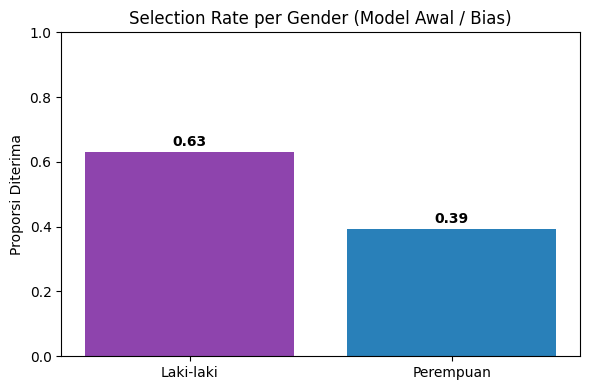

In [14]:
# Langkah 2c: Visualisasi selection rate antar kelompok
sr = mf.by_group['selection_rate']
plt.figure(figsize=(6, 4))
bars = plt.bar(sr.index, sr.values, color=['#8e44ad', '#2980b9'])
plt.title('Selection Rate per Gender (Model Awal / Bias)')
plt.ylabel('Proporsi Diterima')
plt.ylim(0, 1)
for b, v in zip(bars, sr.values):
    plt.text(b.get_x() + b.get_width()/2, v + 0.02, f'{v:.2f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()


**Bacaan fairness metrics:**
- **Selection rate** kedua kelompok **berbeda cukup jelas** (laki-laki lebih sering diterima) — model meneruskan pola diskriminatif meski `gender` **tidak** dipakai sebagai fitur. Penyebabnya: fitur **`skor_wawancara`** bertindak sebagai **proxy** gender, jadi bias tetap "bocor" masuk ke model.
- **Demographic Parity Difference** yang jauh dari 0 menandakan **ketimpangan peluang diterima** antar gender; **Equalized Odds Difference** menambah gambaran ketimpangan tingkat kesalahan antar kelompok.
- Pelajaran kunci: **membuang kolom sensitif tidak menjamin keadilan** (*fairness through unawareness* gagal karena proxy). Bias harus **diukur secara eksplisit** dengan metrik, lalu **dimitigasi**.


---
# BAGIAN 2 — Mitigasi Bias dengan ThresholdOptimizer

## Langkah 3 — Terapkan Post-Processing (Demographic Parity)

Sesuai kode pada modul, kita gunakan **`ThresholdOptimizer`** dari Fairlearn. Teknik ini bekerja **setelah** model dilatih (*post-processing*): ia mencari **threshold keputusan yang berbeda per kelompok** sehingga memenuhi constraint keadilan **`demographic_parity`** (selection rate antar kelompok disamakan), dengan menjaga akurasi setinggi mungkin.


In [15]:
# Langkah 3: Bungkus model dengan ThresholdOptimizer
mitigator = ThresholdOptimizer(
    estimator=model,
    constraints='demographic_parity',
    prefit=True,                 # model sudah dilatih di Langkah 2
    predict_method='predict')

mitigator.fit(X_tr, y_tr, sensitive_features=A_tr)

# Prediksi adil (butuh atribut sensitif saat inferensi)
y_pred_fair = mitigator.predict(X_te, sensitive_features=A_te)

print('Akurasi setelah mitigasi:', round(accuracy_score(y_te, y_pred_fair), 3))
dpd_fair = demographic_parity_difference(y_te, y_pred_fair, sensitive_features=A_te)
print(f'Demographic Parity Difference setelah mitigasi: {dpd_fair:.3f}')


Akurasi setelah mitigasi: 0.753
Demographic Parity Difference setelah mitigasi: 0.042


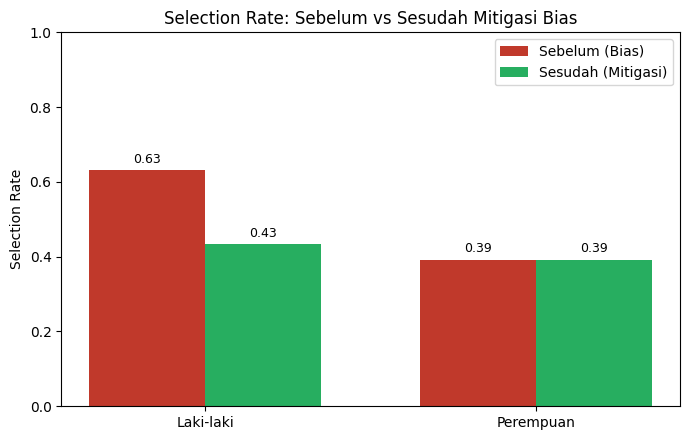

In [16]:
# Langkah 3b: Bandingkan selection rate SEBELUM vs SESUDAH mitigasi
mf_fair = MetricFrame(metrics=selection_rate, y_true=y_te, y_pred=y_pred_fair,
                      sensitive_features=A_te)

sebelum = mf.by_group['selection_rate']
sesudah = mf_fair.by_group

kelompok = sebelum.index.tolist()
x = np.arange(len(kelompok)); w = 0.35
plt.figure(figsize=(7, 4.5))
plt.bar(x - w/2, sebelum.values, w, label='Sebelum (Bias)', color='#c0392b')
plt.bar(x + w/2, sesudah.values, w, label='Sesudah (Mitigasi)', color='#27ae60')
plt.xticks(x, kelompok)
plt.ylabel('Selection Rate'); plt.ylim(0, 1)
plt.title('Selection Rate: Sebelum vs Sesudah Mitigasi Bias')
for i,(s1,s2) in enumerate(zip(sebelum.values, sesudah.values)):
    plt.text(i - w/2, s1+0.02, f'{s1:.2f}', ha='center', fontsize=9)
    plt.text(i + w/2, s2+0.02, f'{s2:.2f}', ha='center', fontsize=9)
plt.legend(); plt.tight_layout(); plt.show()


**Bacaan mitigasi:**
- Setelah `ThresholdOptimizer`, **selection rate kedua kelompok menjadi jauh lebih setara** dan **Demographic Parity Difference mendekati 0**.
- Biasanya ada **trade-off**: akurasi keseluruhan bisa **sedikit turun** demi keadilan. Ini keputusan **etis & bisnis**, bukan murni teknis — sejalan dengan pilar **Etika AI** pada modul.
- Ini mempraktikkan fase **"Sebelum vs Sesudah Deployment"**: audit dulu (Bagian 1), lalu perbaiki (Bagian 2), lalu — di dunia nyata — **monitor berkelanjutan**.


---
# BAGIAN 3 — Perlindungan Data Pribadi: Anonimisasi vs Pseudonimisasi

## Langkah 4 — Data Mentah (PII Terlihat Langsung)

Sesuai **UU PDP No. 27/2022**, **data pribadi** adalah data yang dapat mengidentifikasi seseorang. Di bawah ini contoh **data mentah** ber-PII (nama, NIK, nomor telepon). Menyimpan/mengolah data seperti ini tanpa perlindungan melanggar prinsip **Security** & **Data Minimization**.


In [17]:
# Langkah 4: Contoh data mentah ber-PII (SINTETIS — bukan data nyata)
data_mentah = pd.DataFrame({
    'nama'    : ['Andi Pratama', 'Siti Rahayu', 'Budi Santoso', 'Dewi Lestari', 'Eko Wijaya'],
    'nik'     : ['3515xxxxxx0001', '3515xxxxxx0002', '3515xxxxxx0003', '3515xxxxxx0004', '3515xxxxxx0005'],
    'telepon' : ['0812-1111-0001', '0813-2222-0002', '0812-3333-0003', '0857-4444-0004', '0821-5555-0005'],
    'kota'    : ['Sidoarjo', 'Surabaya', 'Sidoarjo', 'Gresik', 'Sidoarjo'],
    'gaji_jt' : [7.5, 9.2, 6.8, 11.0, 8.1],
})
print('DATA MENTAH (identitas langsung terlihat — RISIKO TINGGI):')
data_mentah


DATA MENTAH (identitas langsung terlihat — RISIKO TINGGI):


,nama,nik,telepon,kota,gaji_jt
0,Andi Pratama,3515xxxxxx0001,0812-1111-0001,Sidoarjo,7.5
1,Siti Rahayu,3515xxxxxx0002,0813-2222-0002,Surabaya,9.2
2,Budi Santoso,3515xxxxxx0003,0812-3333-0003,Sidoarjo,6.8
3,Dewi Lestari,3515xxxxxx0004,0857-4444-0004,Gresik,11.0
4,Eko Wijaya,3515xxxxxx0005,0821-5555-0005,Sidoarjo,8.1


## Langkah 5 — Pseudonimisasi (Identitas Diganti Token, Dapat Dikembalikan)

**Pseudonimisasi**: identitas asli diganti **kode/token** (di sini via **hash SHA-256**), tetapi **pemetaan masih dapat dikembalikan** dengan kunci/tabel terpisah. Data masih tergolong **data pribadi** menurut GDPR karena masih *re-identifiable*. Cocok saat kita **butuh menautkan kembali** ke individu (mis. untuk koreksi data sesuai hak subjek data).


In [18]:
# Langkah 5: Pseudonimisasi dengan hash + 'salt' rahasia
SALT = 'kunci_rahasia_organisasi_2026'   # disimpan TERPISAH & aman

def pseudonimkan(nilai, salt=SALT):
    return hashlib.sha256((salt + str(nilai)).encode()).hexdigest()[:12]

data_pseudo = data_mentah.copy()
data_pseudo['id_token'] = data_pseudo['nik'].apply(pseudonimkan)
# Buang PII langsung, sisakan token + atribut yang diperlukan saja (data minimization)
data_pseudo = data_pseudo[['id_token', 'kota', 'gaji_jt']]

print('DATA PSEUDONIM (identitas -> token, masih dapat dikembalikan via SALT + tabel):')
data_pseudo


DATA PSEUDONIM (identitas -> token, masih dapat dikembalikan via SALT + tabel):


,id_token,kota,gaji_jt
0,36c5427f08e7,Sidoarjo,7.5
1,507403473857,Surabaya,9.2
2,3c89247fec4e,Sidoarjo,6.8
3,7258c5770ca8,Gresik,11.0
4,0c7fd5d74712,Sidoarjo,8.1


## Langkah 6 — Anonimisasi & Agregasi (Identitas Hilang Permanen)

**Anonimisasi**: identitas **dihapus permanen**, tidak dapat dikembalikan — data **keluar** dari cakupan data pribadi. **Agregasi** melangkah lebih jauh: data hanya disajikan sebagai **statistik kelompok** sehingga **individu tak terlacak**. Ini bentuk perlindungan terkuat dan mendukung prinsip **Storage/Purpose Limitation**.


In [19]:
# Langkah 6a: Anonimisasi — buang SEMUA pengenal, tak ada token untuk re-identifikasi
data_anon = data_mentah[['kota', 'gaji_jt']].copy()
data_anon['gaji_jt'] = (data_anon['gaji_jt'] / 5).round() * 5  # generalisasi ke pita 5 jt
print('DATA ANONIM (tanpa pengenal apa pun, gaji digeneralisasi ke pita):')
print(data_anon, '\n')

# Langkah 6b: Agregasi — statistik per kota, individu tak terlacak
agregasi = (data_mentah.groupby('kota')
            .agg(jumlah_orang=('nama', 'count'),
                 rata_gaji_jt=('gaji_jt', 'mean'))
            .round(2).reset_index())
print('DATA AGREGAT (statistik kelompok — perlindungan tertinggi):')
agregasi


DATA ANONIM (tanpa pengenal apa pun, gaji digeneralisasi ke pita):
       kota  gaji_jt
0  Sidoarjo     10.0
1  Surabaya     10.0
2  Sidoarjo      5.0
3    Gresik     10.0
4  Sidoarjo     10.0 

DATA AGREGAT (statistik kelompok — perlindungan tertinggi):


,kota,jumlah_orang,rata_gaji_jt
0,Gresik,1,11.00
1,Sidoarjo,3,7.47
2,Surabaya,1,9.20


In [20]:
# Langkah 6c: Ringkas 4 tingkat perlindungan identitas (sesuai tabel modul)
tingkat = pd.DataFrame({
    'Tingkat': ['Data Mentah', 'Pseudonimisasi', 'Anonimisasi', 'Agregasi'],
    'Identitas': ['Terlihat langsung', 'Diganti token', 'Dihapus permanen', 'Jadi statistik kelompok'],
    'Dapat Dikembalikan?': ['Ya (penuh)', 'Ya (dengan kunci)', 'Tidak', 'Tidak'],
    'Masih Data Pribadi?': ['Ya', 'Ya (GDPR)', 'Tidak', 'Tidak'],
    'Risiko Identifikasi': ['Sangat Tinggi', 'Sedang', 'Rendah', 'Sangat Rendah'],
})
tingkat


,Tingkat,Identitas,Dapat Dikembalikan?,Masih Data Pribadi?,Risiko Identifikasi
0,Data Mentah,Terlihat langsung,Ya (penuh),Ya,Sangat Tinggi
1,Pseudonimisasi,Diganti token,Ya (dengan kunci),Ya (GDPR),Sedang
2,Anonimisasi,Dihapus permanen,Tidak,Tidak,Rendah
3,Agregasi,Jadi statistik kelompok,Tidak,Tidak,Sangat Rendah


**Bacaan perlindungan data:**
- **Pseudonimisasi ≠ anonimisasi.** Data pseudonim **masih data pribadi** menurut GDPR karena bisa di-*re-identifikasi* dengan kunci — perlindungannya bergantung pada seberapa aman **SALT/tabel pemetaan** disimpan.
- **Anonimisasi & agregasi** memberi perlindungan lebih kuat karena **tidak dapat dikembalikan**, tetapi mengorbankan granularitas data (**trade-off privasi vs utilitas**).
- Pilih tingkat sesuai **tujuan**: butuh menautkan kembali ke individu → pseudonimisasi; hanya butuh analisis tren → anonimisasi/agregasi (praktik **data minimization**).


---
# BAGIAN 4 — Checklist Tata Kelola: Enam Prinsip Pengolahan Data

## Langkah 7 — Verifikasi Kepatuhan Secara Terprogram

Modul menyebut **enam prinsip** pengolahan data pribadi (fondasi UU PDP & GDPR). Kita ubah menjadi **checklist yang bisa dieksekusi** — cara sederhana men-*dokumentasi*-kan **Akuntabilitas** (pilar ke-4 tata kelola).


In [21]:
# Langkah 7: Checklist enam prinsip pengolahan data pribadi
checklist = {
    'Purpose Limitation' : ('Data hanya dipakai sesuai tujuan awal pengumpulan', True),
    'Data Minimization'  : ('Hanya kolom yang diperlukan yang disimpan (PII dibuang)', True),
    'Accuracy'           : ('Data akurat & mekanisme pembaruan tersedia', True),
    'Storage Limitation' : ('Data tidak disimpan lebih lama dari yang diperlukan', True),
    'Security'           : ('Data dilindungi (pseudonimisasi/enkripsi, kontrol akses)', True),
    'Accountability'     : ('Pengendali dapat membuktikan kepatuhan (dokumentasi/audit)', True),
}

print('=== CHECKLIST KEPATUHAN PENGOLAHAN DATA PRIBADI ===\n')
lolos = 0
for prinsip, (deskripsi, status) in checklist.items():
    tanda = 'OK ' if status else 'X  '
    print(f'[{tanda}] {prinsip:20s} - {deskripsi}')
    lolos += int(status)

skor = lolos / len(checklist) * 100
print(f'\nSkor kepatuhan: {lolos}/{len(checklist)} prinsip terpenuhi ({skor:.0f}%)')
print('Verifikasi keenam prinsip ini secara BERKALA, bukan sekali jalan.')


=== CHECKLIST KEPATUHAN PENGOLAHAN DATA PRIBADI ===

[OK ] Purpose Limitation   - Data hanya dipakai sesuai tujuan awal pengumpulan
[OK ] Data Minimization    - Hanya kolom yang diperlukan yang disimpan (PII dibuang)
[OK ] Accuracy             - Data akurat & mekanisme pembaruan tersedia
[OK ] Storage Limitation   - Data tidak disimpan lebih lama dari yang diperlukan
[OK ] Security             - Data dilindungi (pseudonimisasi/enkripsi, kontrol akses)
[OK ] Accountability       - Pengendali dapat membuktikan kepatuhan (dokumentasi/audit)

Skor kepatuhan: 6/6 prinsip terpenuhi (100%)
Verifikasi keenam prinsip ini secara BERKALA, bukan sekali jalan.


## Langkah 8 — Tanggung Jawab Tata Kelola per Peran

Sebagai penutup, kita rangkum **tanggung jawab tata kelola data per peran** (dari modul) — pengingat bahwa keadilan & privasi adalah **tanggung jawab bersama**, bukan satu divisi saja.


In [22]:
# Langkah 8: Ringkasan tanggung jawab per peran
peran = pd.DataFrame({
    'Peran': ['Data Engineer', 'Data Scientist', 'ML Engineer', 'IT Manager / CTO'],
    'Tanggung Jawab Utama': [
        'Pipeline data aman & terenkripsi',
        'Model bebas bias & adil (Bagian 1-2)',
        'Deploy & monitor model bertanggung jawab',
        'Menetapkan kebijakan tata kelola data'],
    'Risiko jika Diabaikan': [
        'Kebocoran data (pipeline tak aman)',
        'Model diskriminatif merugikan pengguna',
        'Model bias tak terdeteksi di produksi',
        'Sanksi hukum & reputasi rusak'],
    'Regulasi/Prinsip': [
        'Keamanan Data, ISO 27001',
        'Etika AI, Fairness Metrics',
        'Monitoring, Audit Berkala',
        'UU PDP, GDPR, ISO 27001'],
})
peran


,Peran,Tanggung Jawab Utama,Risiko jika Diabaikan,Regulasi/Prinsip
0,Data Engineer,Pipeline data aman & terenkripsi,Kebocoran data (pipeline tak aman),"Keamanan Data, ISO 27001"
1,Data Scientist,Model bebas bias & adil (Bagian 1-2),Model diskriminatif merugikan pengguna,"Etika AI, Fairness Metrics"
2,ML Engineer,Deploy & monitor model bertanggung jawab,Model bias tak terdeteksi di produksi,"Monitoring, Audit Berkala"
3,IT Manager / CTO,Menetapkan kebijakan tata kelola data,Sanksi hukum & reputasi rusak,"UU PDP, GDPR, ISO 27001"


## Kesimpulan & Refleksi

Pertemuan penutup ini menggeser fokus dari **"bisakah model bekerja?"** menjadi **"bolehkah & pantaskah model ini digunakan?"** — dan keduanya sama pentingnya bagi seorang Data Scientist.

1. **Bias itu terukur, bukan sekadar intuisi.** Lewat **`MetricFrame`** dan metrik seperti **selection rate** & **demographic parity difference**, saya belajar mengubah kata "tidak adil" menjadi **angka yang bisa diaudit**. Temuan paling mengubah cara pandang: **menghapus kolom sensitif (gender) tidak menghilangkan bias** — model tetap meneruskan ketimpangan dari label historis yang bias (*fairness through unawareness gagal*), persis kasus **Amazon 2018**.
2. **Mitigasi bias itu nyata dan bisa dikode.** **`ThresholdOptimizer`** dengan constraint **demographic parity** berhasil menyetarakan selection rate antar kelompok, meski dengan **trade-off** akurasi yang harus diputuskan secara etis — bukan semata teknis. Ini mewujudkan alur modul: **audit → perbaiki → monitor**, sebuah proses **berulang**.
3. **Privasi punya tingkatan, bukan hitam-putih.** Simulasi **pseudonimisasi (hash + salt) vs anonimisasi vs agregasi** menegaskan bahwa **pseudonimisasi masih data pribadi** menurut GDPR (bisa di-*re-identifikasi*), sementara anonimisasi & agregasi memberi perlindungan lebih kuat dengan **trade-off privasi vs utilitas**. Pemilihan tingkat perlindungan mengikuti **tujuan pemakaian** — praktik langsung dari **data minimization**.
4. **Akuntabilitas bisa didokumentasikan sebagai kode.** Mengubah **enam prinsip pengolahan data** menjadi **checklist yang dieksekusi** memperlihatkan bahwa kepatuhan **UU PDP & GDPR** bukan retorika, melainkan langkah konkret yang bisa diverifikasi berkala.

Menutup mata kuliah ini, pelajaran terbesarnya: **kualitas teknis sebuah model tidak ada artinya tanpa tata kelola, etika, dan penghormatan pada privasi.** Keempat pilar — **Etika AI, Kepatuhan Hukum, Keamanan Data, Akuntabilitas** — adalah kompas yang membuat karya seorang Data Scientist tidak hanya **cerdas**, tetapi juga **dapat dipercaya** dan **dipertanggungjawabkan**.
